# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_: 
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Marana, Kyle
- _Student No._: 2024-14996
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

![Loss of precision in the 'bad' x formula](fig1.png)
**Figure 1. Comparing execution times and deviations in results**

The test case "(coeffs = [(-11)\*\*i for i in reversed(range(8))], x = 11.01)" showed that the naive and Horner methods, despite computing the same polynomial, disagreed by about $3.7 \times 10^{-9}$. This gap comes purely from floating-point rounding: the naive method computes each $x^i$ independently, introducing a fresh rounding error at every power, whereas Horner's method reuses one running result and performs far fewer operations, so errors have less opportunity to build up.

The n = 1 to 500 extension confirmed this pattern at scale. Horner's rule was consistently faster, since it needs only n−1 multiplications vs the naive method's growing count of repeated power computations. Also, the absolute deviation between the two methods grew steadily (and roughly exponentially on the log-scale plot) as degree increased, showing that rounding error compounds worse in the naive approach as more terms are added which is exactly the effect the problem asked us to observe.

### Problem 2: Taylor Series Evaluation

![Loss of precision in the 'bad' x formula](fig2.png)
**Figure 2. $e^x$ plot**

The custom Horner-based Taylor series overlaps almost perfectly with np.exp() across x $x \in [0,10]$. The error panel shows the absolute deviation stays below $4 \times 10^{-9}$ throughout, with no strong upward trend, confirming that using 40 nested terms is more than sufficient to capture e^x accurately even at the largest tested value, x = 10.

![Loss of precision in the 'bad' x formula](fig3.png)
**Figure 3. $\sin(x)$ plot**

No, computing y = x*x requires one exponent evaluation, but every higher power of x needed afterward is generated implicitly through the nested multiplications by y, minimizing the operation to just that single squaring. The custom nested series matches np.sin() closely across the same range, with an even smaller maximum error (~$1.6 \times 10^{-10}$). This tighter accuracy makes sense since $\sin(x)$ stays bounded between -1 and 1, so rounding errors have far less room to accumulate compared to the rapidly growing values of $e^x$.


### Other comments
- In this exercise, I talked, asked, cursed, and had a fight with AI since I had no classmate to ask and bother.
- Unfortunately, I was reliant on AI in this exercise. I don't wish for more suspensions of classes, it's hard to learn on your own. 


---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.


In [7]:
# code here
def poly_naive(coeffs, x):
    total = 0
    for i in range(len(coeffs)):
        total = total + coeffs[i] * x**i
    return total

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). 

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [8]:
# coeffs = [(-11)**i for i in reversed(range(8))]
def poly_horner(coeffs, x):
    n = len(coeffs)
    result = coeffs[n - 1]
    for i in range(n - 2, -1, -1):
        result = result * x + coeffs[i]
    return result

coeffs = [(-11) ** i for i in reversed(range(8))]
x = 11.01
 
val_naive = poly_naive(coeffs, x)
val_horner = poly_horner(coeffs, x)
 
print("Test case: coeffs = [(-11)**i for i in reversed(range(8))], x = 11.01")
print("  Naive result :", val_naive)
print("  Horner result:", val_horner)
print("  |difference| :", abs(val_naive - val_horner))
print()

Test case: coeffs = [(-11)**i for i in reversed(range(8))], x = 11.01
  Naive result : 71056.02362162992
  Horner result: 71056.02362163365
  |difference| : 3.725290298461914e-09



Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

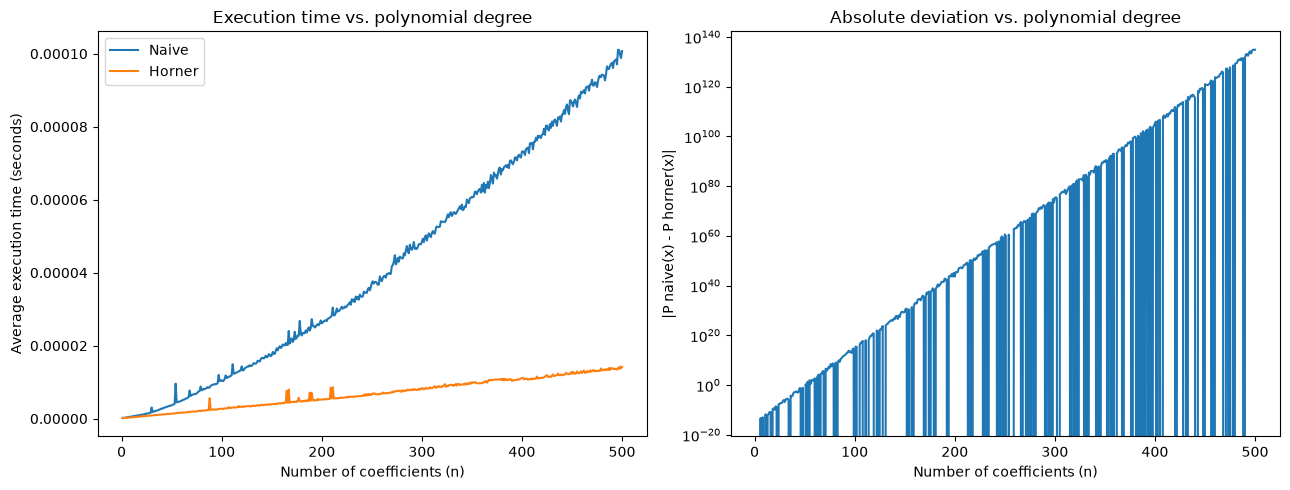

In [12]:
import random
import time
import matplotlib.pyplot as plt
degrees = []
naive_times = []
horner_times = []
deviations = []
 
x_test = 2
REPEATS = 50  # run several times per degree so the timing is not just noise
 
for n in range(1, 501):
 
    # build a random set of coefficients of length n
    coeffs = []
    for i in range(n):
        coeffs.append(random.uniform(-10, 10))
 
    # time the naive function
    start = time.time()
    for repeat in range(REPEATS):
        poly_naive(coeffs, x_test)
    end = time.time()
    naive_time = (end - start) / REPEATS
 
    # time the Horner function
    start = time.time()
    for repeat in range(REPEATS):
        poly_horner(coeffs, x_test)
    end = time.time()
    horner_time = (end - start) / REPEATS
 
    # compute the deviation between the two results
    result_naive = poly_naive(coeffs, x_test)
    result_horner = poly_horner(coeffs, x_test)
    deviation = abs(result_naive - result_horner)
 
    degrees.append(n)
    naive_times.append(naive_time)
    horner_times.append(horner_time)
    deviations.append(deviation)

plt.figure(figsize=(13, 5))
 
plt.subplot(1, 2, 1)
plt.plot(degrees, naive_times, label="Naive")
plt.plot(degrees, horner_times, label="Horner")
plt.xlabel("Number of coefficients (n)")
plt.ylabel("Average execution time (seconds)")
plt.title("Execution time vs. polynomial degree")
plt.legend()
 
plt.subplot(1, 2, 2)
plt.plot(degrees, deviations)
plt.xlabel("Number of coefficients (n)")
plt.ylabel(r"|P naive(x) - P horner(x)|")
plt.title("Absolute deviation vs. polynomial degree")
plt.yscale("log")
 
plt.tight_layout()
plt.show()

#### Problem 1 code summary

This code evaluates a polynomial two ways: poly_naive computes each term directly and sums them, while poly_horner rewrites it in nested form using only n-1 multiplications and no explicit powers. I implemented Horner's version by starting from the highest-degree coefficient and repeatedly applying result = result * x + coeffs[i], mirroring the nested expression from the outside in. The timing and deviation test over degrees 1-500 shows that Horner's rule is both faster and more numerically stable as degree grows, since the naive method's repeated power computations let rounding error build up more.

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

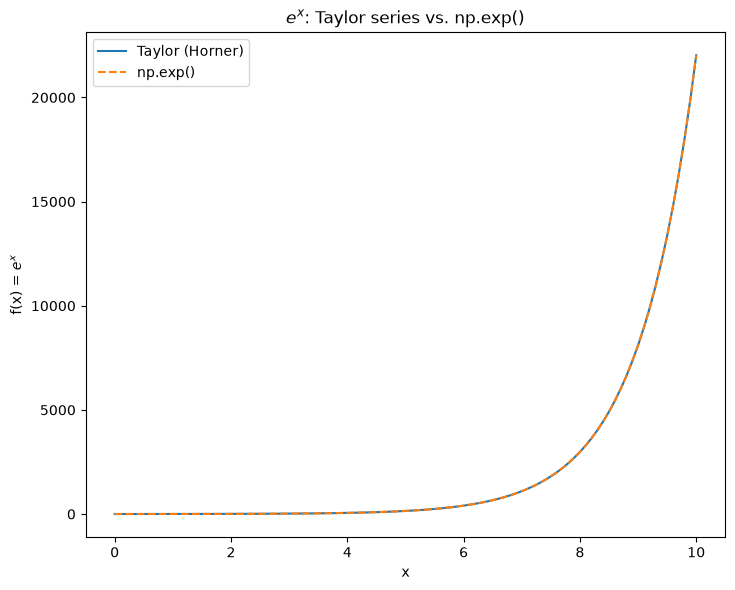

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def exp_horner(x, N=40):
    result = 1
    for k in range(N, 0, -1):
        result = 1 + (x / k) * result
    return result

# Compare with np.exp() over x in [0, 10]
x_values = []
x = 0.0
while x <= 10:
    x_values.append(x)
    x += 0.1
 
exp_custom_values = []
exp_numpy_values = []
for x in x_values:
    exp_custom_values.append(exp_horner(x))
    exp_numpy_values.append(np.exp(x))

plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(x_values, exp_custom_values, label="Taylor (Horner)")
plt.plot(x_values, exp_numpy_values, "--", label="np.exp()")
plt.xlabel("x")
plt.ylabel(r"f(x) = $e^x$")
plt.title(r"$e^x$: Taylor series vs. np.exp()")
plt.legend()  
plt.tight_layout()
 
plt.show()


Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

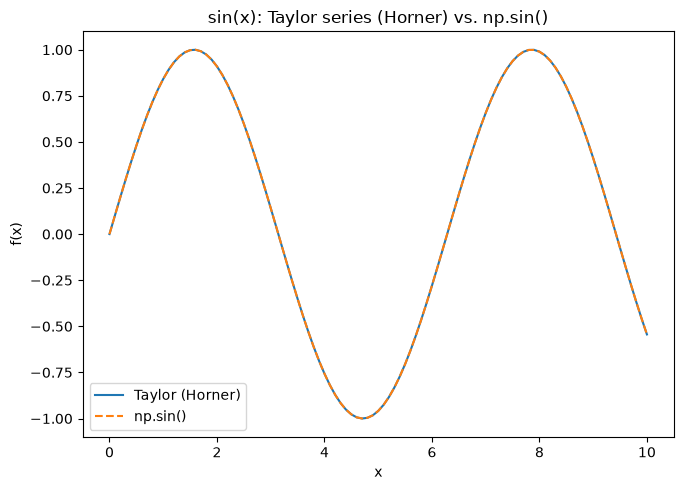

In [6]:
# Compare with np.sin() over x in [0, 10]
def sin_horner(x, N=20):
    y = x * x
    result = 1
    for k in range(N, 0, -1):
        r_k = -1 / ((2 * k) * (2 * k + 1))
        result = 1 + r_k * y * result
    return x * result

sin_custom_values = []
sin_numpy_values = []
for x in x_values:
    sin_custom_values.append(sin_horner(x))
    sin_numpy_values.append(np.sin(x))
 
plt.figure(figsize=(13, 5))
 
plt.subplot(1, 2, 1)
plt.plot(x_values, sin_custom_values, label="Taylor (Horner)")
plt.plot(x_values, sin_numpy_values, "--", label="np.sin()")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("sin(x): Taylor series (Horner) vs. np.sin()")
plt.legend()
 
plt.tight_layout()
plt.show()

#### Problem 2 code summary

This script evaluates e^x and sin(x) using their Taylor series in nested (Horner-like) form, so each term is built from the previous one with one multiplication and division instead of computing separate powers and factorials. For sin(x), y = x*x is computed once up front since only odd powers appear, then the same nested-multiplication approach generates all higher powers implicitly. This keeps both functions efficient and avoids the rounding error buildup that comes from computing powers and factorials separately.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

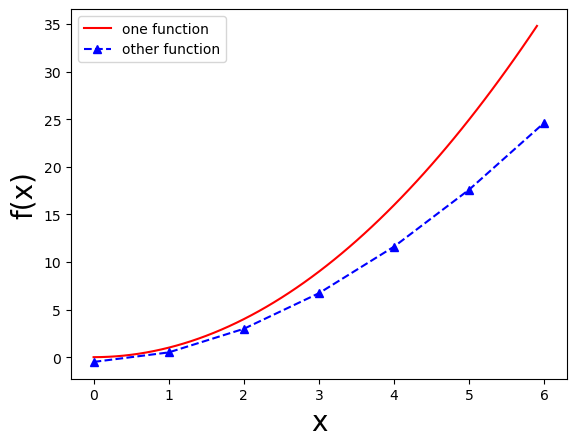

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

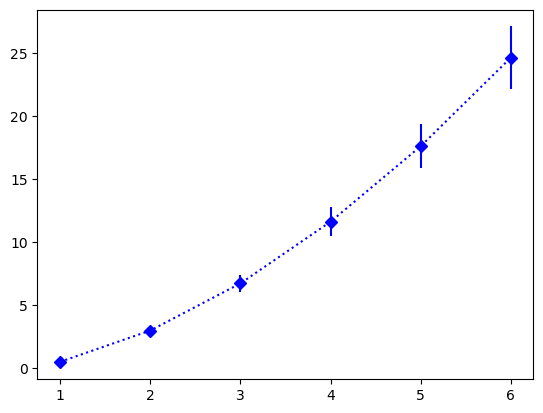

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])